## About Plotly

It is a data visualization library by the company Plotly based out of Canada with support languages such as Python,Javascript,Julia etc


When we already have matplotlib and seaborn why to study plotly ?

1-beautiful plots

2-Multi language support -> Supports Javascript.. if we want to convert graph to website.. if the graph is already made by javascript langauage then it is very easy ... can convert it into javascript

3-Interactive plots: Until now we did visualizations using matplotlib,seaborn and pandas.All of them produce static image files. Plotly creates interactive visualization in the form of HTML Files.

4-Lots of graphs 


Does not work with live data streams. Dash (Sublibrary of plotly) can be explored for that.

## The Plotly Roadmap

1-Plotly Graph Objects --> similar to matplotlib

2-Plotly Express (Abstraction of Plotly Graph objects) --> similar to seaborn

3-Dash (converts graph objects to website ... you can make proper website) --> similar to streamlit



## Working with Plotly Go

In [16]:
## import the libraries

import plotly.graph_objects as go
import plotly.offline as pyo
import numpy as np
import pandas as pd
import plotly.express as px

In [17]:
## import datasets

tips=px.data.tips()
iris=px.data.iris()
gap=px.data.gapminder()

In [18]:
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [19]:
gap.head()


,country,continent,year,lifeExp,pop,gdpPercap,iso_alpha,iso_num
0,Afghanistan,Asia,1952,28.801,8425333,779.445314,AFG,4
1,Afghanistan,Asia,1957,30.332,9240934,820.853030,AFG,4
2,Afghanistan,Asia,1962,31.997,10267083,853.100710,AFG,4
3,Afghanistan,Asia,1967,34.020,11537966,836.197138,AFG,4
4,Afghanistan,Asia,1972,36.088,13079460,739.981106,AFG,4


In [20]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species,species_id
0,5.1,3.5,1.4,0.2,setosa,1
1,4.9,3.0,1.4,0.2,setosa,1
2,4.7,3.2,1.3,0.2,setosa,1
3,4.6,3.1,1.5,0.2,setosa,1
4,5.0,3.6,1.4,0.2,setosa,1


## Scatter Plot using Plotly go

In [21]:
## scatter plot using plotly go

temp_df=gap[gap['year']==2007]

In [22]:
## create figure just like we did in matplotlib and then we call show function
## figure has two arguments...data-> plot graph and layout->design graph (fontsize, x axis pe kya hoga,y axis pe kya hoga)

trace1=go.Scatter(x=temp_df['lifeExp'],y=temp_df['gdpPercap'],mode='markers')
data=[trace1]
layout=go.Layout(title='Life exp vs GDP per captia for 2007',xaxis={'title':'Life Exp'},yaxis={'title':'GDP'})
fig=go.Figure(data,layout)
fig.show()

In [ ]:
trace1=go.Scatter(x=temp_df['lifeExp'],y=temp_df['gdpPercap'],mode='markers',text=temp_df['continent'],marker={'color':'#00a65a','size':10})
trace2=go.Scatter(x=[0,1,2],y=[0,90,300000],mode='lines')
data=[trace1,trace2]
layout=go.Layout(title='Life exp vs GDP per captia for 2007',xaxis={'title':'Life Exp'},yaxis={'title':'GDP'})
fig=go.Figure(data,layout)
fig.show() ## can also use pyo.plot(fig)

In [32]:
trace1=go.Scatter(x=temp_df['lifeExp'],y=temp_df['gdpPercap'],mode='markers',text=temp_df['continent'],marker={'color':'#00a65a','size':10})
trace2=go.Scatter(x=[0,1,2],y=[0,90,300000],mode='lines')
data=[trace1,trace2]
layout=go.Layout(title='Life exp vs GDP per captia for 2007',xaxis={'title':'Life Exp'},yaxis={'title':'GDP'})
fig=go.Figure(data,layout)
pyo.plot(fig,filename='myfile.html')

'myfile.html'

In [163]:
match=pd.read_csv('/Users/priyanshugupta/Desktop/plotly/matches.csv')
delivery=pd.read_csv('/Users/priyanshugupta/Desktop/plotly/deliveries.csv')

ipl=delivery.merge(match,left_on='match_id',right_on='id')
top50=ipl.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False).head(50).index.to_list()
new_ipl=ipl[ipl['batter'].isin(top50)]
runs=new_ipl.groupby('batter')['batsman_runs'].sum()
balls=new_ipl.groupby('batter')['batsman_runs'].count()
sr=(runs/balls)*100
sr=sr.reset_index()
out=ipl[ipl['player_dismissed'].isin(top50)]
nouts=out['player_dismissed'].value_counts()
avg=runs/nouts
avg=avg.reset_index()
avg.rename(columns={'index':'batter',0:'avg'},inplace=True)
avg=avg.merge(sr,on='batter')

## Linechart using pyplot go

In [40]:
## extension of scatter plot
## for time series data

single=ipl[ipl['batter']=='V Kohli']
performance=single.groupby('season')['batsman_runs'].sum().reset_index()
performance

,season,batsman_runs
0,2007/08,165
1,2009,246
2,2009/10,307
3,2011,557
4,2012,364
5,2013,639
6,2014,359
7,2015,505
8,2016,973
9,2017,308


In [45]:


trace=go.Scatter(x=performance['season'],y=performance['batsman_runs'],mode='lines+markers',marker={'color':'#00a65a'})

data=[trace]

layout=go.Layout(title='year by year performance',xaxis={'title':'season'},yaxis={'title':'total_runs'})


fig=go.Figure(data=data,layout=layout)

fig.show()

In [50]:
single1=ipl[ipl['batter']=='V Kohli']
performance1=single1.groupby('season')['batsman_runs'].sum().reset_index()
single2=ipl[ipl['batter']=='MS Dhoni']
performance2=single2.groupby('season')['batsman_runs'].sum().reset_index()



trace1=go.Scatter(x=performance1['season'],y=performance1['batsman_runs'],mode='lines+markers',marker={'color':'#00a65a'},name='Virat Kohli')
trace2=go.Scatter(x=performance2['season'],y=performance2['batsman_runs'],mode='lines+markers',marker={'color':"#a6005b"},name='MS dhoni')

data=[trace1,trace2]
layout=go.Layout(title='year by year performance',xaxis={'title':'season'},yaxis={'title':'total_runs'})


fig=go.Figure(data=data,layout=layout)

fig.show()

In [55]:
## multiple line charts

def batsman_comp(*name):
    data=[]
    for i in name:
        single=ipl[ipl['batter']==i]
        performance=single.groupby('season')['batsman_runs'].sum().reset_index()
        trace=go.Scatter(x=performance['season'],y=performance['batsman_runs'],name=i,mode='lines+markers')
        data.append(trace)
    
    layout=go.Layout(title='Bastman Record Comparator',xaxis={'title':'Season'},yaxis={'title':'Runs'})
    fig=go.Figure(data=data,layout=layout)
    pyo.plot(fig,filename='year_by_year')

batsman_comp('V Kohli','MS Dhoni','DA Warner','RG Sharma')

/opt/anaconda3/lib/python3.13/site-packages/plotly/offline/offline.py:556: UserWarning:

Your filename `year_by_year` didn't end with .html. Adding .html to the end of your file.



## Barplot

In [66]:
## show relation between one categorical and 1 numerical data


top10=ipl.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False).head(10).index.to_list()
top10_df=ipl[ipl['batter'].isin(top10)]
top10_score=top10_df.groupby('batter')['batsman_runs'].sum().reset_index()
top10_score

,batter,batsman_runs
0,AB de Villiers,5181
1,CH Gayle,4997
2,DA Warner,6567
3,KD Karthik,4843
4,MS Dhoni,5243
5,RG Sharma,6630
6,RV Uthappa,4954
7,S Dhawan,6769
8,SK Raina,5536
9,V Kohli,8014


In [68]:
## plot bar graph

trace=go.Bar(x=top10_score['batter'],y=top10_score['batsman_runs'])
data=[trace]

layout=go.Layout(title='top 10 IPL batsman',
                 xaxis={'title':'Batsman'},
                 yaxis={'title':'Total Runs'})

fig=go.Figure(data,layout)
pyo.plot(fig)

'temp-plot.html'

## 2 Types of Bar Graphs

1-Nested Bar graphs

2-Stacked Bar Graphs

3-Overlayed Bar Graphs

In [ ]:
## Overlayed

iw=top10_df.groupby(['batter','inning'])['batsman_runs'].sum().reset_index()
mask=iw['inning']==1
mask2=iw['inning']==2

one=iw[mask]
two=iw[mask2]


one.rename(columns={"batsman_runs":'1st Innings'},inplace=True)
two.rename(columns={'batsman_runs':'2nd Innings'},inplace=True)
final=one.merge(two,on='batter')[['batter','1st Innings','2nd Innings']]


trace1=go.Bar(x=final['batter'],y=final['1st Innings'],name='1st Innings',marker={'color':"#00a65a"})
trace2=go.Bar(x=final['batter'],y=final['2nd Innings'],name='2nd Innings',marker={'color':"#a6a67a"})

data=[trace1,trace2]

layout=go.Layout(title='Innings wise score',
                 xaxis={'title':'Batsman'},
                 yaxis={'title':'Runs'},
                 barmode='overlay')

fig=go.Figure(data=data,layout=layout)

fig.show()

/var/folders/gg/f1jqwyw902s1lt078gd0wfdm0000gn/T/ipykernel_9597/3412416838.py:9: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/gg/f1jqwyw902s1lt078gd0wfdm0000gn/T/ipykernel_9597/3412416838.py:10: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [ ]:
## stacked

iw=top10_df.groupby(['batter','inning'])['batsman_runs'].sum().reset_index()
mask=iw['inning']==1
mask2=iw['inning']==2

one=iw[mask]
two=iw[mask2]


one.rename(columns={"batsman_runs":'1st Innings'},inplace=True)
two.rename(columns={'batsman_runs':'2nd Innings'},inplace=True)
final=one.merge(two,on='batter')[['batter','1st Innings','2nd Innings']]


trace1=go.Bar(x=final['batter'],y=final['1st Innings'],name='1st Innings',marker={'color':"#00a65a"})
trace2=go.Bar(x=final['batter'],y=final['2nd Innings'],name='2nd Innings',marker={'color':"#a6a67a"})

data=[trace1,trace2]

layout=go.Layout(title='Innings wise score',
                 xaxis={'title':'Batsman'},
                 yaxis={'title':'Runs'},
                 barmode='stack')

fig=go.Figure(data=data,layout=layout)

fig.show()

/var/folders/gg/f1jqwyw902s1lt078gd0wfdm0000gn/T/ipykernel_9597/1834410137.py:9: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/gg/f1jqwyw902s1lt078gd0wfdm0000gn/T/ipykernel_9597/1834410137.py:10: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [80]:
## nested

iw=top10_df.groupby(['batter','inning'])['batsman_runs'].sum().reset_index()
mask=iw['inning']==1
mask2=iw['inning']==2

one=iw[mask]
two=iw[mask2]


one.rename(columns={"batsman_runs":'1st Innings'},inplace=True)
two.rename(columns={'batsman_runs':'2nd Innings'},inplace=True)
final=one.merge(two,on='batter')[['batter','1st Innings','2nd Innings']]


trace1=go.Bar(x=final['batter'],y=final['1st Innings'],name='1st Innings',marker={'color':"#00a65a"})
trace2=go.Bar(x=final['batter'],y=final['2nd Innings'],name='2nd Innings',marker={'color':"#a6a67a"})

data=[trace1,trace2]

layout=go.Layout(title='Innings wise score',
                 xaxis={'title':'Batsman'},
                 yaxis={'title':'Runs'},
                 )

fig=go.Figure(data=data,layout=layout)

fig.show()

/var/folders/gg/f1jqwyw902s1lt078gd0wfdm0000gn/T/ipykernel_9597/2651833991.py:11: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/gg/f1jqwyw902s1lt078gd0wfdm0000gn/T/ipykernel_9597/2651833991.py:12: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



## Bubble Plot

In [166]:
top50=ipl.groupby('batter')['batsman_runs'].sum().sort_values(ascending=False).head(50).index.to_list()

new_ipl=new_ipl[new_ipl['batsman_runs']==6]
six=new_ipl.groupby('batter')['batsman_runs'].count().reset_index()
x=avg.merge(six,on='batter')

trace=go.Scatter(x=x['avg'],y=x['batsman_runs_x'],mode='markers',marker={'size':x['batsman_runs_y']})
data=[trace]

layout=go.Layout(title='Bubble Chart',
                 xaxis={'title':'Average'},
                 yaxis={'title':'SR'})
fig=go.Figure(data,layout)
fig.show()

## Boxplot

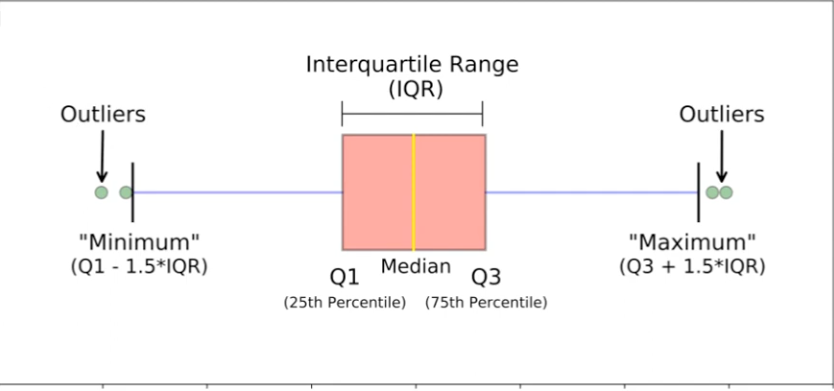

In [167]:
match_agg=delivery.groupby('match_id')['total_runs'].sum().reset_index()
season_wise=match_agg.merge(match,left_on='match_id',right_on='id')[['match_id','total_runs','season']]
season_wise

,match_id,total_runs,season
0,335982,304,2007/08
1,335983,447,2007/08
2,335984,261,2007/08
3,335985,331,2007/08
4,335986,222,2007/08
...,...,...,...
1090,1426307,429,2024
1091,1426309,323,2024
1092,1426310,346,2024
1093,1426311,314,2024


In [168]:
trace=go.Box(x=season_wise['total_runs'],name='All seasons')
data=[trace]

layout=go.Layout(title='Total score analysis',
                 xaxis={'title':'total score'})

fig=go.Figure(data,layout)

fig.show()

In [169]:
trace1 = go.Box(
    x=season_wise[season_wise['season']=='2017']['total_runs'],
    name='2017',
    orientation='h'
)

trace2 = go.Box(
    x=season_wise[season_wise['season']=='2012']['total_runs'],
    name='2012',
    orientation='h'
)
data=[trace1,trace2]

layout=go.Layout(title='Total score analysis',
                 xaxis={'title':'total score'})

fig=go.Figure(data=data,layout=layout)

fig.show()

## Displots

In [172]:
## combination of plots: kde, histplot, rugplot



import plotly.figure_factory as ff
hist_data=[avg['avg']] ## write all the columns here
group_labels=['Average']

fig=ff.create_distplot(hist_data,group_labels)
pyo.plot(fig)

'temp-plot.html'

In [174]:
import plotly.figure_factory as ff
hist_data=[avg['avg'],avg['batsman_runs']] ## write all the columns here
group_labels=['Average','Strike Rate']

fig=ff.create_distplot(hist_data,group_labels,bin_size=[10,20])
pyo.plot(fig)

'temp-plot.html'

## Histograms

In [178]:
x=delivery.groupby('batter')['batsman_runs'].count() > 150
x=x[x].index.tolist()
new=delivery[delivery['batter'].isin(x)]
runs=new.groupby('batter')['batsman_runs'].sum()
balls=new.groupby('batter')['batsman_runs'].count()
sr=(runs/balls)*100
sr=sr.reset_index()
sr

,batter,batsman_runs
0,A Ashish Reddy,142.857143
1,A Badoni,125.544554
2,A Manohar,127.624309
3,A Mishra,86.590909
4,A Symonds,124.711908
...,...,...
235,Y Venugopal Rao,113.872832
236,YBK Jaiswal,146.757991
237,YK Pathan,138.046272
238,YV Takawale,104.918033


In [182]:
trace=go.Histogram(x=sr['batsman_runs'],name='strikerate variation',xbins={'size':2})
data=[trace]
layout=go.Layout(title='strike rate analysis',
                 xaxis={'title':'strike rates'})
fig=go.Figure(data,layout)

fig.show()

In [183]:
trace=go.Histogram(x=sr['batsman_runs'],name='strikerate variation',xbins={'size':2,'start':50,'end':100})
data=[trace]
layout=go.Layout(title='strike rate analysis',
                 xaxis={'title':'strike rates'})
fig=go.Figure(data,layout)

fig.show()

## Heatmap

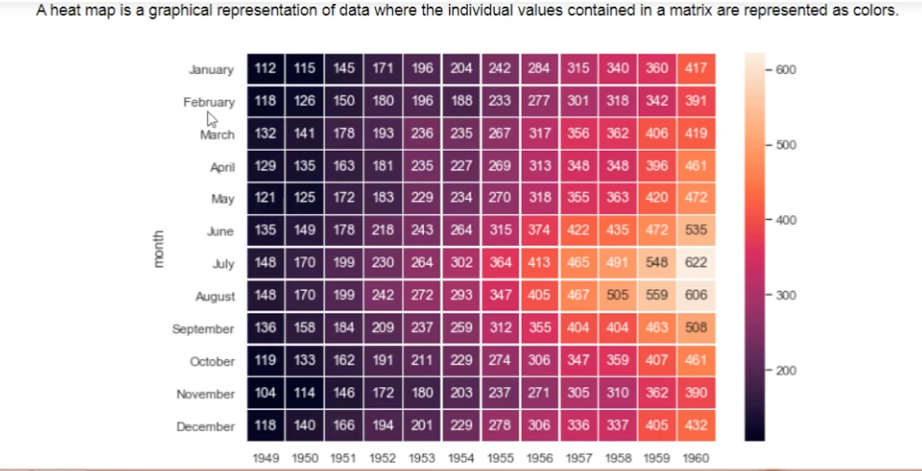

In [186]:
six=delivery[delivery['batsman_runs']==6]
six=six.groupby(['batting_team','over'])['batsman_runs'].count().reset_index()
six

,batting_team,over,batsman_runs
0,Chennai Super Kings,0,9
1,Chennai Super Kings,1,36
2,Chennai Super Kings,2,67
3,Chennai Super Kings,3,71
4,Chennai Super Kings,4,75
...,...,...,...
371,Sunrisers Hyderabad,15,56
372,Sunrisers Hyderabad,16,59
373,Sunrisers Hyderabad,17,73
374,Sunrisers Hyderabad,18,94


In [192]:
trace=go.Heatmap(x=six['batting_team'],y=six['over'],z=six['batsman_runs'])
data=[trace]
layout=go.Layout(title='six heatmap',
                 xaxis={'title':'batting teams'},
                 yaxis={'title':'over'})

fig=go.Figure(data,layout)


fig.show()

In [196]:
dots=delivery[delivery['batsman_runs']==0]
dots=dots.groupby(['batting_team','over'])['batsman_runs'].count().reset_index()

##side by side heatmap


from plotly import tools

trace1=go.Heatmap(x=six['batting_team'],y=six['over'],z=six['batsman_runs'].values.tolist())
trace2=go.Heatmap(x=dots['batting_team'],y=dots['over'],z=dots['batsman_runs'].values.tolist())

fig=tools.make_subplots(rows=1,cols=2,subplot_titles=["6's","0's"],shared_yaxes=True)
fig.append_trace(trace1,1,1)
fig.append_trace(trace2,1,2)

fig.show()
